# Tutorial: fmdtools basics

::: {.content-hidden}
```
Copyright © 2024, United States Government, as represented by the Administrator of the National Aeronautics and Space Administration. All rights reserved.

The “"Fault Model Design tools - fmdtools version 2"” software is licensed under the Apache License, Version 2.0 (the "License"); you may not use this file except in compliance with the License. You may obtain a copy of the License at http://www.apache.org/licenses/LICENSE-2.0. 

Unless required by applicable law or agreed to in writing, software distributed under the License is distributed on an "AS IS" BASIS, WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied. See the License for the specific language governing permissions and limitations under the License.
```
:::

## Overview
This tutorial shows the basics of:

1. working with fmdtools to model a system (in this example, a multirotor drone with a few variants), 

2. simulating a model in nominal and hazardous scenarios, and

3. analyzing and visualizing the results of simulations. 

## Multorotor Drone folder

The `multirotor_drone` folder has a few different models that are meant to represent **different types of models** that can be built in fmdtools (in terms of fidelity) and showcase how **more detailed models** can be built from **less detailed models.**

The models in this folder include:

- `model_static.py`: a multirotor drone simulated at a single timestep with very basic abstract behaviors to capture failure propagation in a "static flight" case

- `model_dynamic.py`: an extended version of this drone with dynamic behaviors (e.g., basic flight dynamics, battery usage, etc.)

- `model_hierarchical.py`: a version with multiple component architectures embodying the "StoreEE" (battery architecture) and "AffectDOF" (line/rotor architecture) functions

- `model_rural.py`: a version that flies in a rural scenario (viewing the area in a field)

- `model_urban.py`: a version that over buildings in an urban setting 

## Multirotor Drone Structure 

Models in fmdtools can take many different forms, depending on the use-case. When we want to model how different behaviors of a system interact, we often represent the system as a `FunctionArchitecture` that is made up of `Function` objects that are connected with each other via `Flow` objects.

## Drone Functions

- `store_ee`: Store the electrical energy that powers the system (e.g., batteries)

- `dist_ee`: Distribute the electrical energy that powers the system (e.g., wiring and circuitry)

- `affect_dof`: Modify the position and velocity of the system (e.g., rotor architecture)

- `ctl_dof`: Control the position and velocity of the system to its desired state (e.g., control system)

- `plan_path`: Plan the desired trajectory of the drone and produce the neccesary controls (e.g., navigation)

- `hold_payload`: Structurally support the weight of the drone and its payloads (e.g., structures)

- `view_env`: View the environment (e.g., camera)


## Drone Flows

- `force_st`: Force connecting the body of the drone with the ground

- `force_lin`: Force connecting the rotors with the body of the drone

- `ee_1`: Electricity out of the battery (to be distributed)

- `ee_mot`: Electricity to the motors

- `ee_ctl`: Electricity to the electronics

- `ctl`: Control signals to the motors

- `dofs`: Degrees of freedom (trajectory, velocity) of the drone

- `des_traj`: Desired trajectory of the drone


## Drone model file

To get an idea of what a model file looks like (as well as the different pieces), look through `model_static.py`. Here we import this model to look at its structure:

In [1]:
import inspect
from fmdtools_examples.multirotor_drone.model_static import Drone, EE, StoreEE
print(inspect.getsource(Drone))

class Drone(FunctionArchitecture):
    """Static multirotor drone model (executes in a single timestep)."""

    default_sp = {'end_time': 0}

    def init_architecture(self, **kwargs):
        # add flows to the model
        self.add_flow("force_st", Force)
        self.add_flow("force_lin", Force)
        self.add_flow("ee_1", EE)
        self.add_flow("ee_mot", EE)
        self.add_flow("ee_ctl", EE)
        self.add_flow("ctl", Control)
        self.add_flow("dofs", DOFs)
        self.add_flow("des_traj", DesTraj)
        # add functions to the model
        self.add_fxn("store_ee", StoreEE, "ee_1", "force_st")
        self.add_fxn("dist_ee", DistEE, "ee_1", "ee_mot", "ee_ctl", "force_st")
        self.add_fxn("affect_dof", AffectDOF, "ee_mot", "ctl", "dofs", "force_lin")
        self.add_fxn("ctl_dof", CtlDOF, "ee_ctl", "des_traj", "ctl", "dofs", "force_st")
        self.add_fxn("plan_path", PlanPath, "ee_ctl", "des_traj", "force_st", "dofs")
        self.add_fxn("hold_payload", 

## Drone Architecture

To instantiate the model, you can use:

In [2]:
mdl = Drone()
mdl

drone Drone
- t=Time(time=-0.1, timers={})
- m=Mode(mode='nominal', faults=set(), sub_faults=False)
FLOWS:
- force_st=Force(s=(support=1.0))
- force_lin=Force(s=(support=1.0))
- ee_1=EE(s=(rate=1.0, effort=1.0))
- ee_mot=EE(s=(rate=1.0, effort=1.0))
- ee_ctl=EE(s=(rate=1.0, effort=1.0))
- ctl=Control(s=(forward=1.0, upward=1.0))
- dofs=DOFs(s=(vertvel=1.0, planvel=1.0, planpwr=1.0, uppwr=1.0, x=0.0, y=0.0, z=0.0))
- des_traj=DesTraj(s=(dx=1.0, dy=0.0, dz=0.0, power=1.0))
FXNS:
- store_ee=StoreEE(s=(soc=100.0), m=(mode='nominal', faults=set(), sub_faults=False))
- dist_ee=DistEE(s=(ee_tr=1.0, ee_te=1.0), m=(mode='nominal', faults=set(), sub_faults=False))
- affect_dof=AffectDOF(s=(e_to=1.0, e_ti=1.0, ct=1.0, mt=1.0, pt=1.0), m=(mode='nominal', faults=set(), sub_faults=False))
- ctl_dof=CtlDOF(s=(cs=1.0, power=1.0), m=(mode='nominal', faults=set(), sub_faults=False))
- plan_path=PlanPath(m=(mode='nominal', faults=set(), sub_faults=False))
- hold_payload=HoldPayload(s=(force_gr=1.0), m=(m

## Interacting with a FunctionArchitecture

It can be helpful to look at the major pieces of a the Drone class:

In [3]:
mdl.sp # simulation parameter--determines how long the simulation will run and in what configuration

SimParam(phases=(('na', 0.0, 0),), start_time=0.0, end_time=0.0, track_times=('all',), dt=1.0, units='hr', end_condition='', use_local=True, with_loadings=False, run_stochastic=False, track_pdf=False)

In [4]:
mdl.fxns # flow dictionary

{'store_ee': store_ee StoreEE
 - t=Time(time=-0.1, timers={})
 - s=StoreEEState(soc=100.0)
 - m=StoreEEMode(mode='nominal', faults=set(), sub_faults=False)
 - ee_out=EE(s=(rate=1.0, effort=1.0))
 - fs=Force(s=(support=1.0)),
 'dist_ee': dist_ee DistEE
 - t=Time(time=-0.1, timers={})
 - s=DistEEState(ee_tr=1.0, ee_te=1.0)
 - m=DistEEMode(mode='nominal', faults=set(), sub_faults=False)
 - ee_in=EE(s=(rate=1.0, effort=1.0))
 - ee_mot=EE(s=(rate=1.0, effort=1.0))
 - ee_ctl=EE(s=(rate=1.0, effort=1.0))
 - st=Force(s=(support=1.0)),
 'affect_dof': affect_dof AffectDOF
 - t=Time(time=-0.1, timers={})
 - s=AffectDOFState(e_to=1.0, e_ti=1.0, ct=1.0, mt=1.0, pt=1.0)
 - m=AffectDOFMode(mode='nominal', faults=set(), sub_faults=False)
 - ee_in=EE(s=(rate=1.0, effort=1.0))
 - ctl_in=Control(s=(forward=1.0, upward=1.0))
 - dofs=DOFs(s=(vertvel=1.0, planvel=1.0, planpwr=1.0, uppwr=1.0, x=0.0, y=0.0, z=0.0))
 - force=Force(s=(support=1.0)),
 'ctl_dof': ctl_dof CtlDOF
 - t=Time(time=-0.1, timers={})
 - 

In [5]:
mdl.flows

{'force_st': force_st Force
 - s=ForceState(support=1.0),
 'force_lin': force_lin Force
 - s=ForceState(support=1.0),
 'ee_1': ee_1 EE
 - s=EEState(rate=1.0, effort=1.0),
 'ee_mot': ee_mot EE
 - s=EEState(rate=1.0, effort=1.0),
 'ee_ctl': ee_ctl EE
 - s=EEState(rate=1.0, effort=1.0),
 'ctl': ctl Control
 - s=ControlState(forward=1.0, upward=1.0),
 'dofs': dofs DOFs
 - s=DOFstate(vertvel=1.0, planvel=1.0, planpwr=1.0, uppwr=1.0, x=0.0, y=0.0, z=0.0),
 'des_traj': des_traj DesTraj
 - s=DesTrajState(dx=1.0, dy=0.0, dz=0.0, power=1.0)}

As shown, each function has its connected flows as a part of its definition.

The result is a graph of behaviors (functions) that interact via shared variables (flows)  

Note that some of the flow names appear different at the function level than the architecture level. This is because they have been given local flow names.

In [6]:
mdl.fxns['store_ee'] # see flow "fs" - at the architecture level this was force_st!

store_ee StoreEE
- t=Time(time=-0.1, timers={})
- s=StoreEEState(soc=100.0)
- m=StoreEEMode(mode='nominal', faults=set(), sub_faults=False)
- ee_out=EE(s=(rate=1.0, effort=1.0))
- fs=Force(s=(support=1.0))

In [7]:
mdl.fxns['store_ee'].fs # while the local variable name is fs, it is still the force_st that we want (that connects other pieces)

force_st Force
- s=ForceState(support=1.0)

In [8]:
mdl.fxns['store_ee'].fs.s.support = 2.0
mdl.fxns['hold_payload'].force_st  # see!

force_st Force
- s=ForceState(support=2.0)

## Viewing the drone architecture

The behavioral interactions between functions via flows can be visualized as a graph:

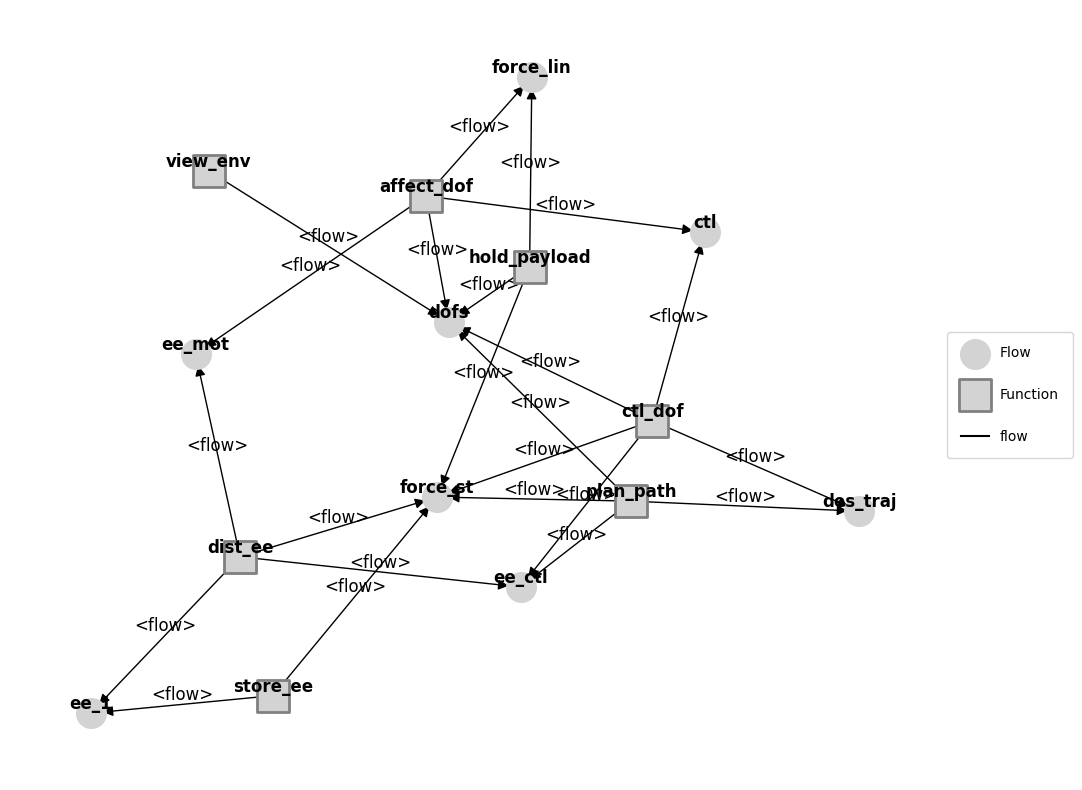

In [9]:
mg = mdl.as_modelgraph()
fig, ax = mg.draw()

This graph is often pretty ugly by default because the layout is auto-generated via an algorithm in the `networkx` package

## Making the graph pretty(er)

The "Model Graph" object that was output by this inherits from the [Graph](https://nasa.github.io/fmdtools/docs-source/fmdtools.analyze.graph.html#fmdtools-analyze-graph-base) class (which heavily uses the `networkx` library), which has built-in options for applying different styles and moving nodes.

In [10]:
# %matplotlib qt5  # use this to have the graphs open up in an external window you can interact with
# mg.move_nodes() # this lets you move the nodes around in the external window
# %matplotlib inline  # this puts the matplotlib output back in the notebook

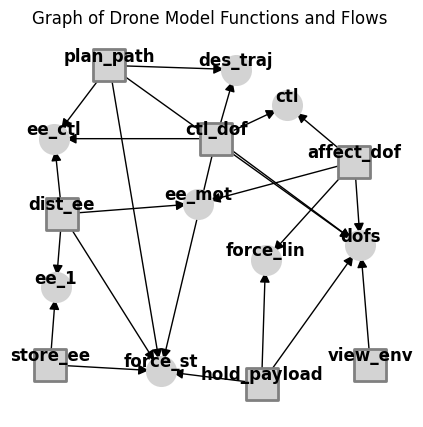

In [11]:
from model_static import pos
mg.set_pos(**pos)
mg.set_edge_labels(title="")
fig, ax = mg.draw(title="Graph of Drone Model Functions and Flows", withlegend=False, figsize=(5,5))

More info on working with graphs can be found in [Tutorial: Model Structure Visualization](https://nasa.github.io/fmdtools/examples/navigating_rover/tutorial_model_structure_visualization.html)

## Simulation

There are several ways to simulate fmdtools models. One of the most flexible is to use the model directly:

In [12]:
mdl(0)
mdl

drone Drone
- t=Time(time=0.0, timers={})
- m=Mode(mode='nominal', faults=set(), sub_faults=False)
FLOWS:
- force_st=Force(s=(support=1.0))
- force_lin=Force(s=(support=1.0))
- ee_1=EE(s=(rate=1.0, effort=1.0))
- ee_mot=EE(s=(rate=1.0, effort=1.0))
- ee_ctl=EE(s=(rate=1.0, effort=1.0))
- ctl=Control(s=(forward=1.0, upward=1.0))
- dofs=DOFs(s=(vertvel=0.0, planvel=1.0, planpwr=1.0, uppwr=1.0, x=0.0, y=0.0, z=1.0))
- des_traj=DesTraj(s=(dx=1.0, dy=0.0, dz=0.0, power=1.0))
FXNS:
- store_ee=StoreEE(s=(soc=100.0), m=(mode='nominal', faults=set(), sub_faults=False))
- dist_ee=DistEE(s=(ee_tr=1.0, ee_te=1.0), m=(mode='nominal', faults=set(), sub_faults=False))
- affect_dof=AffectDOF(s=(e_to=1.0, e_ti=1.0, ct=1.0, mt=1.0, pt=1.0), m=(mode='nominal', faults=set(), sub_faults=False))
- ctl_dof=CtlDOF(s=(cs=1.0, power=1.0), m=(mode='nominal', faults=set(), sub_faults=False))
- plan_path=PlanPath(m=(mode='nominal', faults=set(), sub_faults=False))
- hold_payload=HoldPayload(s=(force_gr=0.0), m=(mo

Note the change in state in the system--most notably the incremented timestep (now 1).

## Simulation Limitation

Since this model is only meant to run one timestep, simulating further gives us an error:

In [13]:
# mdl()

## Simulation Parameter and History

Models can be run to different times depending on their Simulation Parameter (see: [SimParam](https://nasa.github.io/fmdtools/docs-source/fmdtools.define.block.html#fmdtools.define.block.base.SimParam). The static model, by default, only simulates one timestep at `t=0`:

In [14]:
mdl.sp # simulation parameter

SimParam(phases=(('na', 0.0, 0),), start_time=0.0, end_time=0.0, track_times=('all',), dt=1.0, units='hr', end_condition='', use_local=True, with_loadings=False, run_stochastic=False, track_pdf=False)

This parameter can be changed at model instantiation and sets the end condition (in this case, `end_time`), which in turn determines how long the simulation will run and how long the history is. See:

In [15]:
mdl = Drone(sp={'end_time': 2})
mdl.h

time:                           array(3)
flows.force_st.s.support:       array(3)
flows.force_lin.s.support:      array(3)
flows.ee_1.s.rate:              array(3)
flows.ee_1.s.effort:            array(3)
flows.ee_mot.s.rate:            array(3)
flows.ee_mot.s.effort:          array(3)
flows.ee_ctl.s.rate:            array(3)
flows.ee_ctl.s.effort:          array(3)
flows.ctl.s.forward:            array(3)
flows.ctl.s.upward:             array(3)
flows.dofs.s.vertvel:           array(3)
flows.dofs.s.planvel:           array(3)
flows.dofs.s.planpwr:           array(3)
flows.dofs.s.uppwr:             array(3)
flows.dofs.s.x:                 array(3)
flows.dofs.s.y:                 array(3)
flows.dofs.s.z:                 array(3)
flows.des_traj.s.dx:            array(3)
flows.des_traj.s.dy:            array(3)
flows.des_traj.s.dz:            array(3)
flows.des_traj.s.power:         array(3)
fxns.store_ee.s.soc:            array(3)
fxns.store_ee.m.faults.nocharge: array(3)
fxns.store_ee.m

## Simulation: A more interesting case

To better showcase simulation, we are going to use the model in `model_dynamic.py`

This model builds on the architecture of the Drone model in `model_static.py` but adds behaviors that increment over time, meaning we can look at the behavior over multiple timesteps.

In [16]:
from model_dynamic import Drone

mdl = Drone()
mdl.sp

SimParam(phases=(('ascend', 0, 1), ('forward', 2, 14), ('descend', 15, 18), ('taxi', 19, 20)), start_time=0.0, end_time=20.0, track_times=('all',), dt=1.0, units='sec', end_condition='', use_local=True, with_loadings=False, run_stochastic=False, track_pdf=False)

A single timestep simulates via:

In [17]:
mdl()
mdl.t

Time(time=1.0, t_ind=1, timers={}, use_local=True, dt=1.0, executed_static=True, executed_dynamic=True, executing=False)

Or, to a given time-step:

In [18]:
mdl(time=20.0)

In [19]:
mdl.t

Time(time=20.0, t_ind=20, timers={}, use_local=True, dt=1.0, executed_static=True, executed_dynamic=True, executing=False)

## Examining Simulation States

Given we've simulated the model to a given time-step, we can examine the states of the system and its history to see what happened:

In [20]:
mdl.fxns['store_ee'].s

StoreEEState(soc=89.5)

In [21]:
mdl.h.fxns.store_ee.s.soc

array([99.5, 99. , 98.5, 98. , 97.5, 97. , 96.5, 96. , 95.5, 95. , 94.5,
       94. , 93.5, 93. , 92.5, 92. , 91.5, 91. , 90.5, 90. , 89.5])

The `classify` method defined in the Model can also be used to classify the results of a given scenario.

In [22]:
from fmdtools.sim.scenario import Scenario
mdl.classify(scen=Scenario())

{'rate': 1.0, 'cost': 0, 'expected_cost': 0.0, 'lost_cost': 0, 'crashcost': 0}

We might want to be able to know more about the states of the system as a whole! We'll cover more of that in the analysis portion of the tutorial.

## Using the `sim.propagate` module

While you can always simulate models directly, `sim.propagate` has a lot of functionality that makes it easier to simulate scenarios of interest.

In [23]:
from fmdtools.sim import propagate

The simplest is `propagate.nominal`, which simulates the nominal scenario. Propagate methods return `Result` and `History` objects, like so:

In [24]:
res, hist = propagate.nominal(mdl)
res

tend.classify.rate:                  1.0
tend.classify.cost:                    0
tend.classify.expected_cost:         0.0
tend.classify.lost_cost:               0
tend.classify.crashcost:               0

In [25]:
hist

time:                          array(21)
flows.force_st.s.support:      array(21)
flows.force_lin.s.support:     array(21)
flows.ee_1.s.rate:             array(21)
flows.ee_1.s.effort:           array(21)
flows.ee_mot.s.rate:           array(21)
flows.ee_mot.s.effort:         array(21)
flows.ee_ctl.s.rate:           array(21)
flows.ee_ctl.s.effort:         array(21)
flows.ctl.s.forward:           array(21)
flows.ctl.s.upward:            array(21)
flows.dofs.s.vertvel:          array(21)
flows.dofs.s.planvel:          array(21)
flows.dofs.s.planpwr:          array(21)
flows.dofs.s.uppwr:            array(21)
flows.dofs.s.x:                array(21)
flows.dofs.s.y:                array(21)
flows.dofs.s.z:                array(21)
flows.des_traj.s.dx:           array(21)
flows.des_traj.s.dy:           array(21)
flows.des_traj.s.dz:           array(21)
flows.des_traj.s.power:        array(21)
flows.environment.c.r.probdens: array(21)
flows.environment.c.viewed:    array(21)
fxns.store_ee.s

## Verifying nominal outputs

With a history, you can use `History.plot_line` to verify that the system progresses through states as expected:

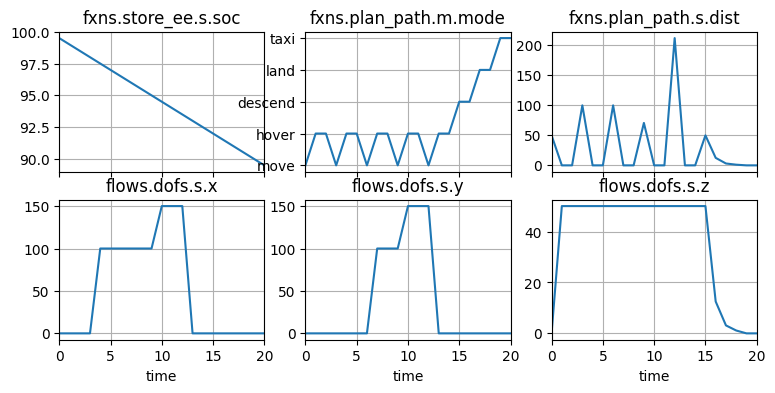

In [26]:
fig, axs = hist.plot_line("fxns.store_ee.s.soc", "fxns.plan_path.m.mode", "fxns.plan_path.s.dist", "flows.dofs.s.x", "flows.dofs.s.y", "flows.dofs.s.z", cols=3)

## Verifying nominal trajectories

For trajectory information (x, y, and z coordinates), you can use `History.plot_trajectories`, which can work when there are two or three variables to plot:

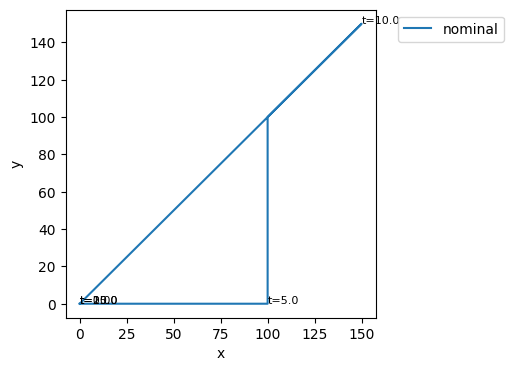

In [27]:
# fix, ax = hist.plot_trajectories("flows.dofs.s.x", "flows.dofs.s.y", "flows.dofs.s.z", time_groups=["nominal"], time_ticks=5.0)
fix, ax = hist.plot_trajectories("flows.dofs.s.x", "flows.dofs.s.y", time_groups=["nominal"], time_ticks=5.0)

## Simulating a fault scenario

We can simulate individual fault scenarios using `propagate.one_fault`. A fault scenario is a combination of a fault mode (defined as `fault_faultname` in a `Mode`) and a time.

Here we inject a `nocharge` fault into the `store_ee` function at time `t=10.0`:

In [28]:
res_lowcharge, hist_lowcharge = propagate.one_fault(mdl, "store_ee", "nocharge", 10.0)
res_lowcharge.faulty

tend.classify.rate:                1e-05
tend.classify.cost:             183000.0
tend.classify.expected_cost:    183000.0
tend.classify.lost_cost:           50000
tend.classify.crashcost:          100000

As shown, this causes a crash since the drone can no longer keep itself in the air:

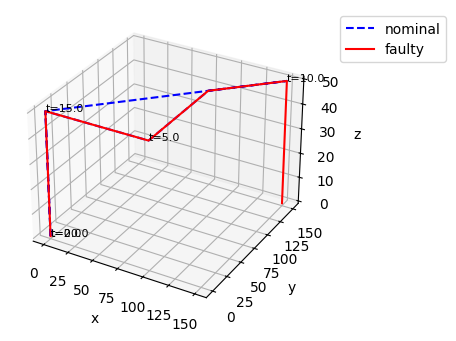

In [29]:
fig, ax = hist_lowcharge.plot_trajectories("flows.dofs.s.x", "flows.dofs.s.y", "flows.dofs.s.z", time_groups=["nominal"], time_ticks=5.0)

## Examining fault scenario results

When simulating scenarios, the returned `Result` and `History` objects include both nominal and faulty scenario information by default. This makes it easier to see what went wrong in a scenario, visualize scenarios and quantify metrics:

In [30]:
res_lowcharge.nest()

nominal: 
--tend: 
----classify: 
------rate:                          1.0
------cost:                            0
------expected_cost:                 0.0
------lost_cost:                       0
------crashcost:                       0
store_ee_nocharge_t10p0: 
--tend: 
----classify: 
------rate:                        1e-05
------cost:                     183000.0
------expected_cost:            183000.0
------lost_cost:                   50000
------crashcost:                  100000

We can get just the fault scenario results at `.faulty` 

In [31]:
res_lowcharge.faulty

tend.classify.rate:                1e-05
tend.classify.cost:             183000.0
tend.classify.expected_cost:    183000.0
tend.classify.lost_cost:           50000
tend.classify.crashcost:          100000

## Fault Graphs

Finally, we can use graphs to display the propagation of faults at any particular time by modifying the default `to_return` input parameter.

In [32]:
res_lowcharge, hist_lowcharge = propagate.one_fault(mdl, "store_ee", "nocharge", 10.0, to_return=['graph'])
res_lowcharge

nominal.tend.graph: <fmdtools.define.architecture.function.FunctionArchitectureGraph object at 0x000001530BE339D0>
store_ee_nocharge_t10p0.tend.graph: <fmdtools.define.architecture.function.FunctionArchitectureGraph object at 0x000001530BE33ED0>

This graph shows **degradations** (blocks where the states deviate from the nominal state) in orange and **faults** (blocks where a fault mode has been entered) in red

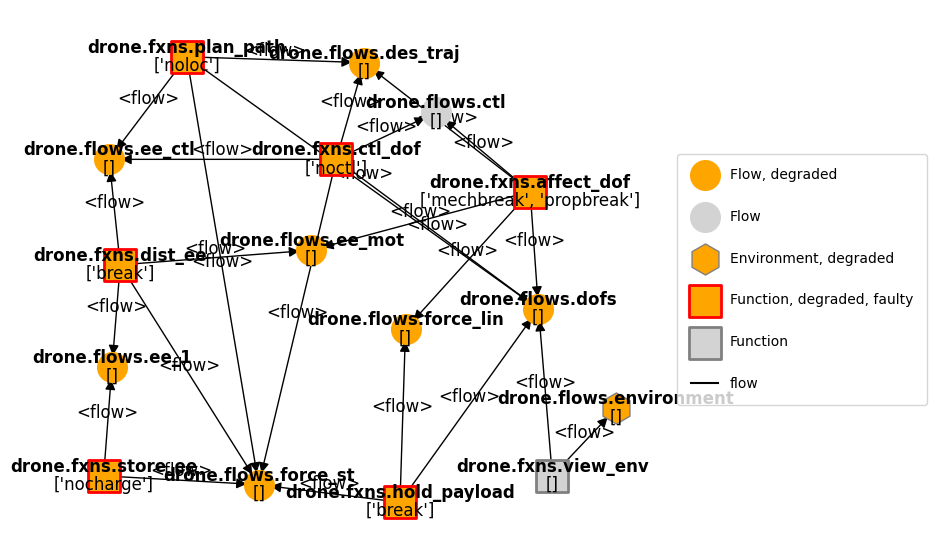

In [33]:
res_lowcharge.faulty.tend.graph.set_pos(**pos, **{'drone.flows.environment':(1.0, -0.4)})
fig, ax = res_lowcharge.faulty.tend.graph.draw(figsize=(8,7))

## More fault returns

We can get results from different times (rather than the end-time) by modifying the `to_return` argument further:

In [34]:
res_lowcharge, hist_lowcharge = propagate.one_fault(mdl, "store_ee", "nocharge", 10.0, to_return={10.0:['graph', 'classify'], "end": ['graph', 'classify']})
res_lowcharge

nominal.t10p0.classify.rate:         1.0
nominal.t10p0.classify.cost:      150000
nominal.t10p0.classify.expected_cost: 15000000000.0
nominal.t10p0.classify.lost_cost:  50000
nominal.t10p0.classify.crashcost: 100000
nominal.t10p0.graph: <fmdtools.define.architecture.function.FunctionArchitectureGraph object at 0x000001530BAC69E0>
nominal.tend.classify.rate:          1.0
nominal.tend.classify.cost:            0
nominal.tend.classify.expected_cost: 0.0
nominal.tend.classify.lost_cost:       0
nominal.tend.classify.crashcost:       0
nominal.tend.graph: <fmdtools.define.architecture.function.FunctionArchitectureGraph object at 0x000001530BAC76F0>
store_ee_nocharge_t1               1e-05
store_ee_nocharge_t1            150300.0
store_ee_nocharge_t1            150300.0
store_ee_nocharge_t1               50000
store_ee_nocharge_t1              100000
store_ee_nocharge_t10p0.t10p0.graph: <fmdtools.define.architecture.function.FunctionArchitectureGraph object at 0x000001530C4F8710>
store_ee_no

As shown on the graph, at `t=10.0`, when the fault is injected, not all of the faults have yet propagated:

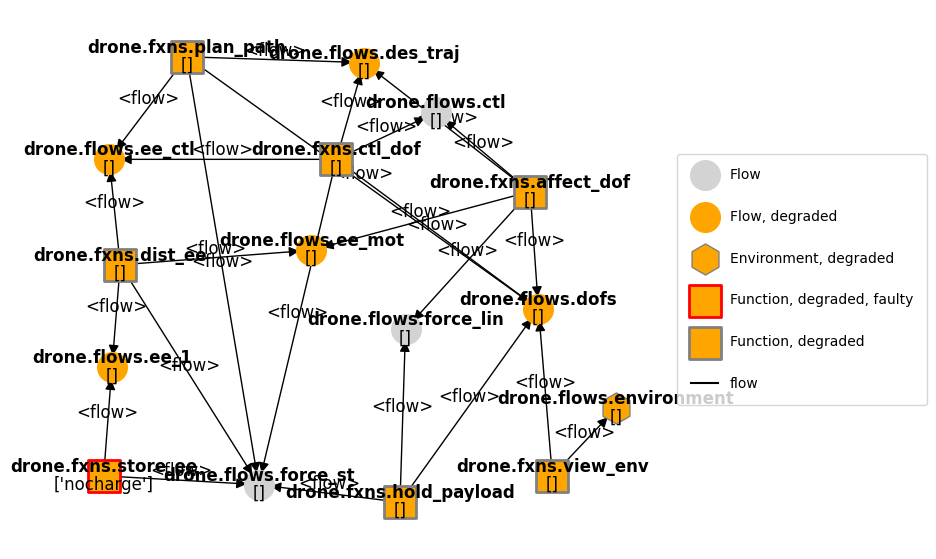

In [35]:
res_lowcharge.faulty.t10p0.graph.set_pos(**pos, **{'drone.flows.environment':(1.0, -0.4)})
fig, ax = res_lowcharge.faulty.t10p0.graph.draw(figsize=(8,7))

## More on single-scenario simulation

Simulation often can mean more than just simulating a fault, but can also include external disturbances or parameters. It may be helpful to familiarize yourself with the following methods:

- `propagate.sequence` method: can be used to inject an arbitrary sequence of disturbances and faults in a model and simulate the results

- `propagate.Simulation` class: gives more fine-grained control over event simulation, including model copying

As well as the options/parameters for these classes and methods.

In [36]:
propagate.sequence

<function fmdtools.sim.propagate.sequence(mdl, seq={}, faultseq={}, disturbances={}, scen={}, rate=nan, include_nominal=True, showprogress=False, **kwargs)>

In [37]:
help(propagate.Simulation)

Help on class Simulation in module fmdtools.sim.propagate:

class Simulation(BaseSimulation)
 |  Simulation(*args, **kwargs)
 |
 |  Simulate a single scenario.
 |
 |  Simulations can be used to do a few things, including:
 |  (1) Simulating a model in a particular faulty or nominal scenario
 |  (2) Getting model copies at particular times during a (usually nominal) scenario
 |  to simulate from. This is helpful for staged simulation where the copies are used
 |  to simulate faults from the point when the fault occurs instead of simulating
 |  up to that timestep first
 |  (3) Generating SampleApproaches that line up with the particular phases of the
 |  (usually nominal) scenario. This is helpful for nested simulations where each
 |  set of nominal parameters may change the phases of the simulation and thus the
 |  fault modes it may enter.
 |
 |  Parameters
 |  ----------
 |  scen : Scenario
 |      Scenario to simulation
 |  protect : bool
 |      Whether to protect the model by re-i

## Simulating many scenarios

The `propagate` method has a few methods available to simulate ranges of nominal parameters, faulty scenarios, and disturbances. To get a feel for how this can be used, we can use `propagate.single_faults`, which simulates all single-fault scenarios possible in a model:

In [38]:
res_sf, hist_sf = propagate.single_faults(mdl, times=[5])

SCENARIOS COMPLETE: 100%|██████████| 20/20 [00:01<00:00, 12.06it/s]


As shown, this pulled 20 possible faults from the model and simulated them at the specified time (t=5). We can see the structure of the results below:

In [39]:
res_sf.nest()

nominal: 
--tend: 
----classify: 
------rate:                          1.0
------cost:                            0
------expected_cost:                 0.0
------lost_cost:                       0
------crashcost:                       0
drone_fxns_store_ee_nocharge_t5: 
--tend: 
----classify: 
------rate:                        1e-05
------cost:                     183000.0
------expected_cost:            183000.0
------lost_cost:                   50000
------crashcost:                  100000
drone_fxns_dist_ee_break_t5: 
--tend: 
----classify: 
------rate:       2.0000000000000003e-06
------cost:                     182700.0
------expected_cost:   36540.00000000001
------lost_cost:                   50000
------crashcost:                  100000
drone_fxns_dist_ee_degr_t5: 
--tend: 
----classify: 
------rate:                        5e-06
------cost:                     183700.0
------expected_cost:   91850.00000000001
------lost_cost:                   50000
------crashcost:      

## Visualizing many faults

We can use the same methods (`plot_line` and `plot_trajectories`) to visualize these results

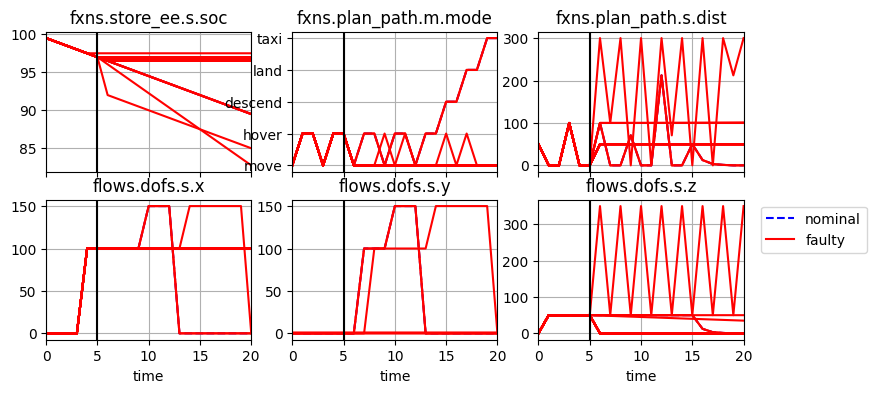

In [40]:
fig, axs = hist_sf.plot_line("fxns.store_ee.s.soc", "fxns.plan_path.m.mode", "fxns.plan_path.s.dist", "flows.dofs.s.x", "flows.dofs.s.y", "flows.dofs.s.z", cols=3, time_slice=[5.0])

## Grouping scenarios

While comparisons of nominal and faulty can be helpful, we can further separate groups based on the `comp_groups` parameter. Here we make each scenario its own group

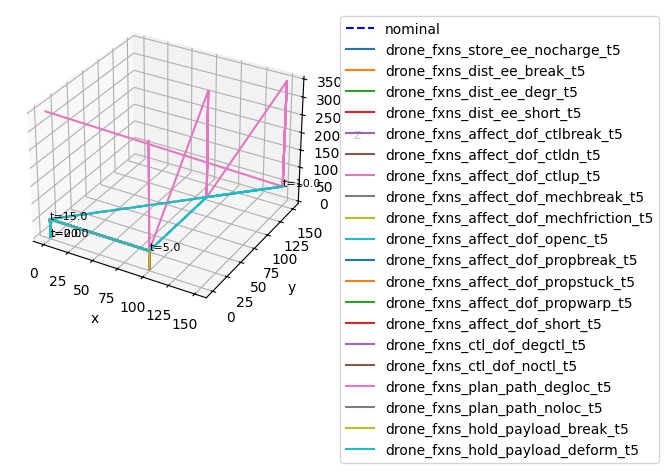

In [41]:
fig, ax = hist_sf.plot_trajectories("flows.dofs.s.x", "flows.dofs.s.y", "flows.dofs.s.z", time_groups=["nominal"], comp_groups={k:k for k in hist_sf.nest()})

As shown, there are three main trajectories--crashing immediately (in grey), flying erratically (the `ctlup` fault in pink), and continuing the mission (in teal). Given this visualization, it may not be clear what scenarios ended in what outcome

More parameters can be used to visualize distributions of outcomes within these groups.

## Aggregating results

Given this multi-scenario simulation, we can view tables of outcomes in aggregate:

In [42]:
tab = res_sf.create_simple_fmea()
tab.head(5) # showing an excerpt of the table

,rate,cost,expected_cost,lost_cost,crashcost
nominal,1.000000,0.0,0.0,0.0,0.0
drone_fxns_store_ee_nocharge_t5,0.000010,183000.0,183000.0,50000.0,100000.0
drone_fxns_dist_ee_break_t5,0.000002,182700.0,36540.0,50000.0,100000.0
drone_fxns_dist_ee_degr_t5,0.000005,183700.0,91850.0,50000.0,100000.0
drone_fxns_dist_ee_short_t5,0.000003,185700.0,55710.0,50000.0,100000.0


Since hazardous outcomes area each given costs, we can use this to get a better idea of which scenarios ended in a crash compared to not having an effect or causing the drone to fly erratically.

## Specifying Scenarios to Simulate

To provide more control over what kinds of scenarios to simulate, fmdtools provides the `sim.sample` module. This module enables the definition of *domains* to sample scenarios from, as well as *samples* of the domain. The main classes provided are:

- `FaultDomain`: Defines faults to sample from.

- `FaultSample`: Defines a set of fault scenarios over a given domain. May be simulated in `propagate.fault_sample`.

- `ParameterDomain`: Defines a range of parameter(s) to sample from.

- `ParameterSample`: Defines a set of parameter values to simulate. May be simulated with `propagate.parameter_sample`

- `SampleApproach`: Defines a combination of `FaultSample`s to be simulated over a `ParameterSample`. May be simulated with `propagate.fault_sample` or constructed with `propagate.nested_sample`

This tutorial will cover basic fault simulation. More materials are provided in [Tutorial: FaultSample](https://nasa.github.io/fmdtools/examples/navigating_rover/tutorial_FaultSample.html) and [Tutorial: ParameterSample](https://nasa.github.io/fmdtools/examples/navigating_rover/tutorial_ParameterSample.html)

## Defining a FaultDomain

We can define the set of faults to sample by first defining a fault domain:

In [43]:
from fmdtools.sim.sample import FaultDomain, FaultSample

fd = FaultDomain(mdl)
fd

FaultDomain with faults:
 -

For this we will need to add faults:

In [44]:
fd.add_fault("drone.fxns.store_ee", "nocharge")
fd.add_fault("drone.fxns.affect_dof", "ctlup")
fd

FaultDomain with faults:
 -('drone.fxns.store_ee', 'nocharge')
 -('drone.fxns.affect_dof', 'ctlup')

There are many more methods we can call from FaultDomain to add faults, including `add_all` (to add all possible fault modes) and `add_all_fxn_modes` (to add all modes from a given function)

## Defining a FaultSample

`FaultSamples` define the set of fault scenarios to simulate based on these faults, given they could be simulated jointly or individually, as well as at different times.

In [45]:
fs = FaultSample(fd)
fs

FaultSample of scenarios: 
 - 

To add particular scenario times, we can use `FaultSample.add_fault_times`. `FaultSample` can also sample particular phases of operation (e.g., takeoff, flight, landing, taxi) statistically using numerical integration provided we give it this information via a `PhaseMap` using `FaultSample.add_fault_phases`.

In [46]:
fs.add_fault_times([5.0, 7.0, 15.0])
fs

FaultSample of scenarios: 
 - drone_fxns_store_ee_nocharge_t5p0
 - drone_fxns_store_ee_nocharge_t7p0
 - drone_fxns_store_ee_nocharge_t15p0
 - drone_fxns_affect_dof_ctlup_t5p0
 - drone_fxns_affect_dof_ctlup_t7p0
 - drone_fxns_affect_dof_ctlup_t15p0

## Simulating a FaultSample

This sample can in turn be simulated with `propagate.fault_sample`

In [47]:
res_fs, hist_fs = propagate.fault_sample(mdl, fs)
[*res_fs.nest(1)]

SCENARIOS COMPLETE: 100%|██████████| 6/6 [00:00<00:00,  6.31it/s]


['nominal',
 'drone_fxns_store_ee_nocharge_t5p0',
 'drone_fxns_store_ee_nocharge_t7p0',
 'drone_fxns_store_ee_nocharge_t15p0',
 'drone_fxns_affect_dof_ctlup_t5p0',
 'drone_fxns_affect_dof_ctlup_t7p0',
 'drone_fxns_affect_dof_ctlup_t15p0']

We can use the `FaultSample` to group and compare particular types of faults, for example:

In [48]:
comp_groups = {k[0]: v for k, v in fs.get_scen_groups("obj").items()}
comp_groups["nominal"] = ["nominal"]
comp_groups

{'drone.fxns.store_ee': ['drone_fxns_store_ee_nocharge_t5p0',
  'drone_fxns_store_ee_nocharge_t7p0',
  'drone_fxns_store_ee_nocharge_t15p0'],
 'drone.fxns.affect_dof': ['drone_fxns_affect_dof_ctlup_t5p0',
  'drone_fxns_affect_dof_ctlup_t7p0',
  'drone_fxns_affect_dof_ctlup_t15p0'],
 'nominal': ['nominal']}

## Visualizing Fault Groups

With particular fault groups defined, we can send them as `comp_groups` argument to various methods:

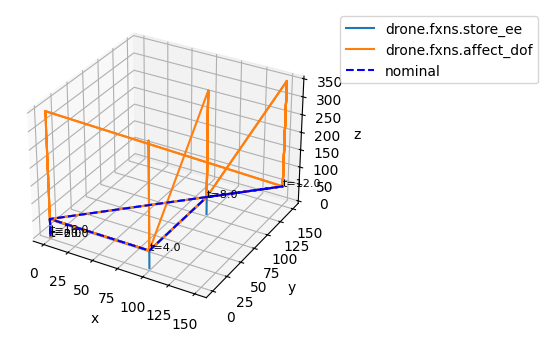

In [49]:

fig, ax = hist_fs.plot_trajectories("flows.dofs.s.x", "flows.dofs.s.y", "flows.dofs.s.z",
                                    comp_groups=comp_groups,
                                    time_groups=['nominal'], time_ticks=4.0)

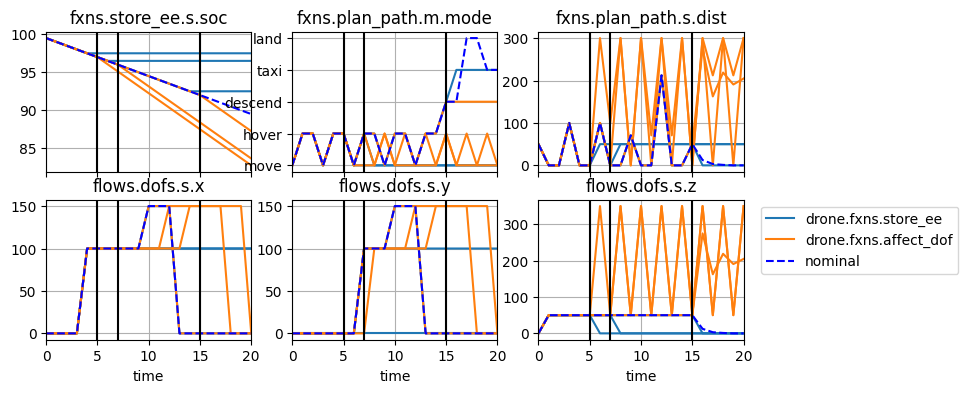

In [50]:
fig, axs = hist_fs.plot_line("fxns.store_ee.s.soc", "fxns.plan_path.m.mode", "fxns.plan_path.s.dist", "flows.dofs.s.x", "flows.dofs.s.y", "flows.dofs.s.z",
                             cols=3, comp_groups=comp_groups, time_slice=[5.0, 7.0, 15.0])

## Tabular Comparison

`FaultSample` can also be used to group scenarios to help us make tables of fault simulation results, e.g., types of Failure Modes and Effects Analysis. See below:

In [51]:
from fmdtools.analyze.tabulate import FMEA, result_summary_fmea
fmeatab = FMEA(res_fs, fs)
fmeatab

<FMEA: 3 metric(s), 2 entries, metrics=['average_scenario_rate', 'sum_cost', 'expected_cost']>

By default, `FMEA` groups all results by function and mode. 

In [52]:
fmeatab.as_table()

,,average_scenario_rate,sum_cost,expected_cost
drone.fxns.store_ee,nocharge,0.000007,499000.0,3.160
drone.fxns.affect_dof,ctlup,0.000001,151500.0,0.202


We can change how this is grouped, e.g.,

In [53]:
fmeatab = FMEA(res_fs, fs, group_by=("time", ))
fmeatab.as_table()

,average_scenario_rate,sum_cost,expected_cost
15.0,0.000006,183500.0,1.4310
7.0,0.000003,233500.0,0.9655
5.0,0.000003,233500.0,0.9655


## Navigating computationally-expensive simulations

As simulations scale and the number of simulations increases, computational time of simulations can become a consideration. There are a few ways to deal with this:

- Keep the simulation time-step low and only simulate the times necessary (e.g., `mdl = Drone(sp={'dt': 5.0})` for a coarser timestep)

- Minimize the number of variables tracked (e.g., `mdl = Drone(track=None)` if a history isn't needed)

- Use the `pool` argument to `propagate` methods so the scenarios can run in parallel (see [tutorial: Using Parallel Computing with fmdtools](https://nasa.github.io/fmdtools/examples/water_pump/tutorial_parallelism.html))

- Save your results so you can load them later using `Result.save`/`History.save` and `Result.load`/`History.load`.


In [54]:
from fmdtools.analyze.history import History
hist_fs.save('outputs_tutorial_fmdtools_basics/hist_fs.csv', overwrite=True)
hist_fs2 = History.load('outputs_tutorial_fmdtools_basics/hist_fs.csv')
hist_fs2

File already exists: outputs_tutorial_fmdtools_basics/hist_fs.csv, writing anyway...


nominal.time:                  array(21)
nominal.flows.force_st.s.support: array(21)
nominal.flows.force_lin.s.support: array(21)
nominal.flows.ee_1.s.rate:     array(21)
nominal.flows.ee_1.s.effort:   array(21)
nominal.flows.ee_mot.s.rate:   array(21)
nominal.flows.ee_mot.s.effort: array(21)
nominal.flows.ee_ctl.s.rate:   array(21)
nominal.flows.ee_ctl.s.effort: array(21)
nominal.flows.ctl.s.forward:   array(21)
nominal.flows.ctl.s.upward:    array(21)
nominal.flows.dofs.s.vertvel:  array(21)
nominal.flows.dofs.s.planvel:  array(21)
nominal.flows.dofs.s.planpwr:  array(21)
nominal.flows.dofs.s.uppwr:    array(21)
nominal.flows.dofs.s.x:        array(21)
nominal.flows.dofs.s.y:        array(21)
nominal.flows.dofs.s.z:        array(21)
nominal.flows.des_traj.s.dx:   array(21)
nominal.flows.des_traj.s.dy:   array(21)
nominal.flows.des_traj.s.dz:   array(21)
nominal.flows.des_traj.s.power: array(21)
nominal.flows.environment.c.r.probdens: array(21)
nominal.flows.environment.c.viewed: arra

## How to Learn More

- The best way to learn fmdtools is to try to build your own model. See if you can build something simple that uses some of the main fmdtools classes (`State`, `Mode`, `Function`, `FunctionArchitecture`, etc.) and simulates in the way you want.

- It can help to look through the `/examples/` folder to see what patterns we have used to model similar systems

- When you are lost, or simply want to know how exactly to use a particular class or function, look at the [Module Reference](file:///C:/Users/dhulse/Documents/GitHub/fmdtools/docs/html/docs-source/fmdtools.html) for for that particular class. This same information is also available using Python's built-in help function (e.g. `help(ClassName)`).

- Finally, ask for help! Sometimes it can be quicker to ask someone who knows than to struggle on your own.
